## The transient Universe

### Tasks

1) Read in `solutions/transient.npy`. This is a (100 x 3) numpy array, containing some time-series measurements from a transient phenomenon. The first column is time (arbitrary units), the second column is the flux (arbitrary units), and the third column are homoescedastic measurement uncertainties on the flux. Plot this data with the uncertainties.

2) One possible model for this data is a sharp burst with an exponential tail rising above a nominal background level. This model can be described as:

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

where $b$ is the background amplitude, $A$ is the burst amplitude, $t_0$ is the burst epoch, and $\alpha$ encodes how rapidly the burst dies off.

Code this burst model, and code a likelihood function for this data with the burst model. *Hint: This is similar in spirit to the likelihood when fitting polynomials to data, except now $x$ is time, and the polynomial model is now the burst model.* 

3) Using one of the MCMC sampler that we looked at in class (`emcee`, `pymc`), perform a Bayesian analysis that recovers an MCMC chain of posterior probability samples for the joint parameter space of $\{b,A,t_0,\alpha\}$. You must decide on how many samples are appropriate for running your MCMC. For your priors, make them $b\in \mathrm{Uniform}[0,50]$, $A\in \mathrm{Uniform}[0,50]$, $t_0\in \mathrm{Uniform}[0,100]$, and $\ln\alpha\in \mathrm{Uniform}[-5,5]$ (careful: uniform in $\ln\alpha$, not $\alpha$).

4) Perform an appropriate check to burn-in your chain, and thin the chain by selecting only points every auto-correlation length. If you are left with a small number of samples after thinning then you may need to run your MCMC for longer in (3).

5) Make a corner plot of the $4$-D parameter space, with labels, $[68,95]\%$ credible levels and quantiles, and titles.

6) Now choose $100$ samples randomly from your burned, thinned chain and plot the $100$ corresponding burst time-series on a figure along with the original data. You may want to choose a transparency for these $100$ burst curves that allows you to see everything nicely. These are showing the posterior spread of model solutions that are consistent with the data.

7) For each parameter, find the median and 90% credible region of the marginalized distribution and quote results as, for instance, $t_0=X^{+Y}_{-Z}$ 



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats 
import emcee
import corner

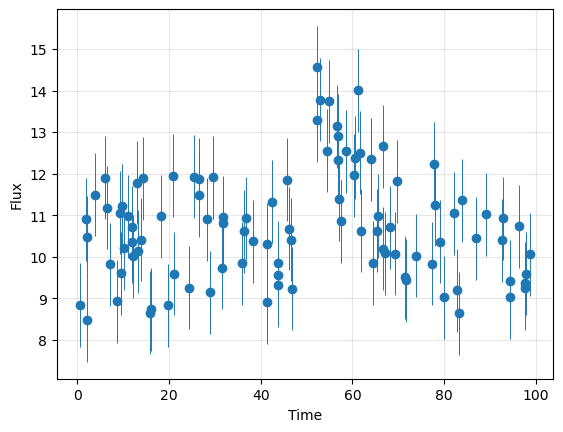

In [2]:
data = np.load("transient.npy")
time = data[:, 0]
flux = data[:, 1]
err = data[:, 2]

plt.errorbar(time, flux, yerr=err, fmt='o', elinewidth=0.7)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.grid(alpha=0.3)

Let's define our model and run an MCMC sapler:

In [3]:
def model(theta, time):
    A, b, alpha, t0 = theta
    y = np.zeros_like(time)
    for i in range(len(time)):
        if time[i] < t0:
            y[i] = b
        else:
            y[i] = b + A * np.exp(-alpha * (time[i] - t0))
    return y

In [4]:
def logLikelihood(theta, flux, time, err):
    return -0.5 * np.sum((flux-model(theta, time))**2 / err**2) 

def logPriors(theta):
    A, b, alpha, t0 = theta
    if (A <= 0 or A > 50) or (b <= 0 or b > 50) or (t0 <= 0 or t0 > 100):
        return -np.inf
    if not (np.exp(-5) <= alpha <= np.exp(5)):
        return -np.inf
    # we can negelct the constant log-priors
    return -np.log(10 * alpha)  #Only term depending on theta

def logPost(theta, flux, time, err):
    lp = logPriors(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + logLikelihood(theta, flux, time, err)

In [ ]:
ndim = 4
nwalkers = 10
nsteps = 10000
theta_test = 5, 10, 0.1, 50

starting_guesses = theta_test + 1e-1* np.random.rand(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, logPost, args=[flux, time, err])
sampler.run_mcmc(starting_guesses, nsteps)

emcee_trace = sampler.chain.reshape(-1, ndim)

Let's look at the traces:

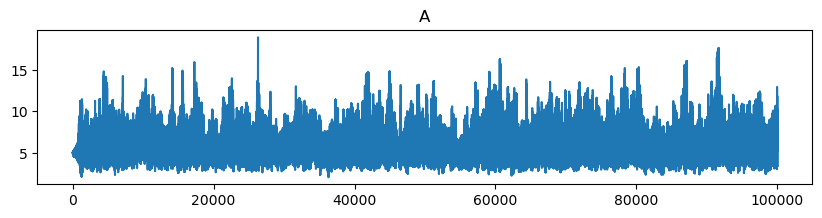

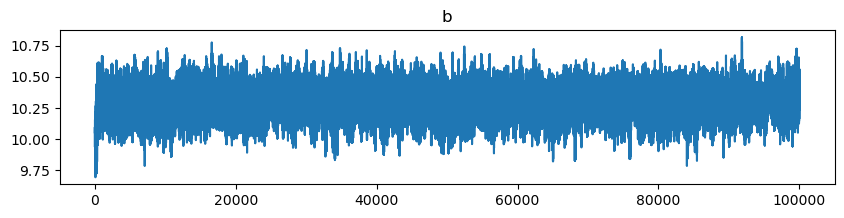

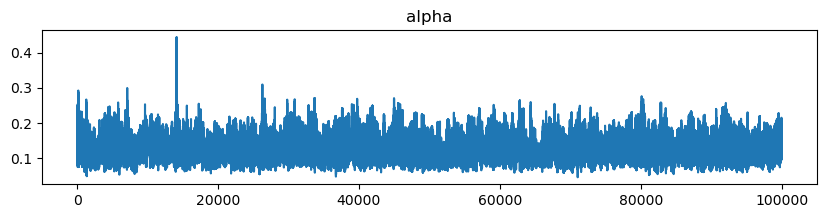

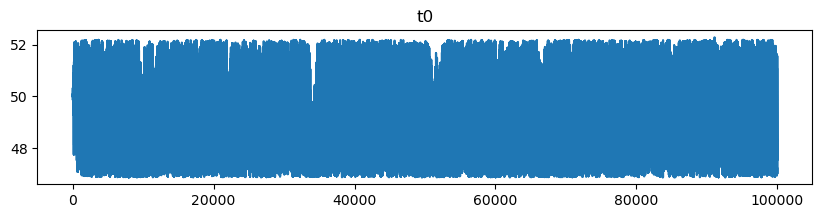

In [6]:
emcee_trace = sampler.get_chain(discard = 0, flat=True)
size = len(emcee_trace[:,0])
X = np.linspace(1, size, size)
labels = ['A', 'b', 'alpha', 't0']

for i in range(len(labels)):
   plt.figure(figsize = (10, 2))
   plt.plot(X, emcee_trace[:, i])
   plt.title(labels[i])

Let's remove some burn-in effect and thin our chain:

Original trace size: 100000
Thinned trace size: 1280


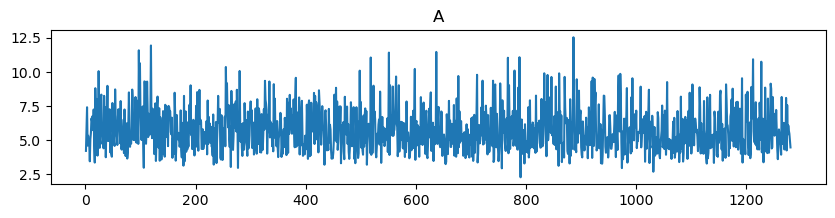

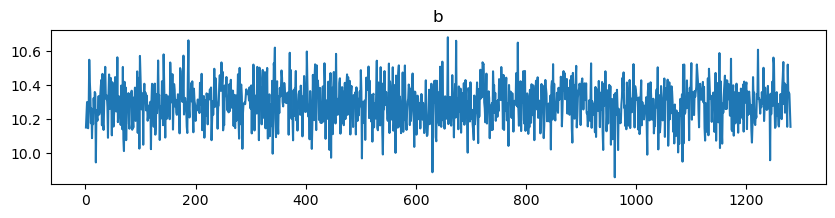

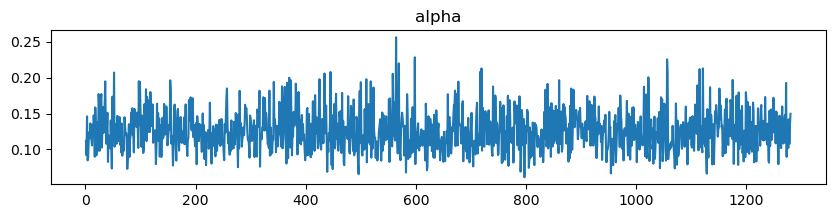

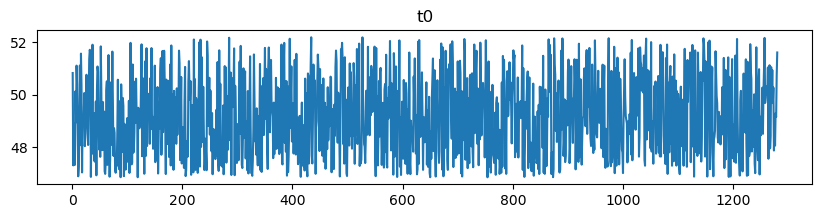

In [7]:
tau = sampler.get_autocorr_time()
thin = int(np.max(tau))
burn = 3*thin

emcee_trace_thin = sampler.get_chain(discard=burn, flat=True, thin=thin)
print(f'Original trace size: {len(emcee_trace)}')
print(f'Thinned trace size: {len(emcee_trace_thin)}')

size = len(emcee_trace_thin[:,0])
X = np.linspace(1, size, size)
labels = ['A', 'b', 'alpha', 't0']

for i in range(len(labels)):
   plt.figure(figsize = (10, 2))
   plt.plot(X, emcee_trace_thin[:, i])
   plt.title(labels[i])

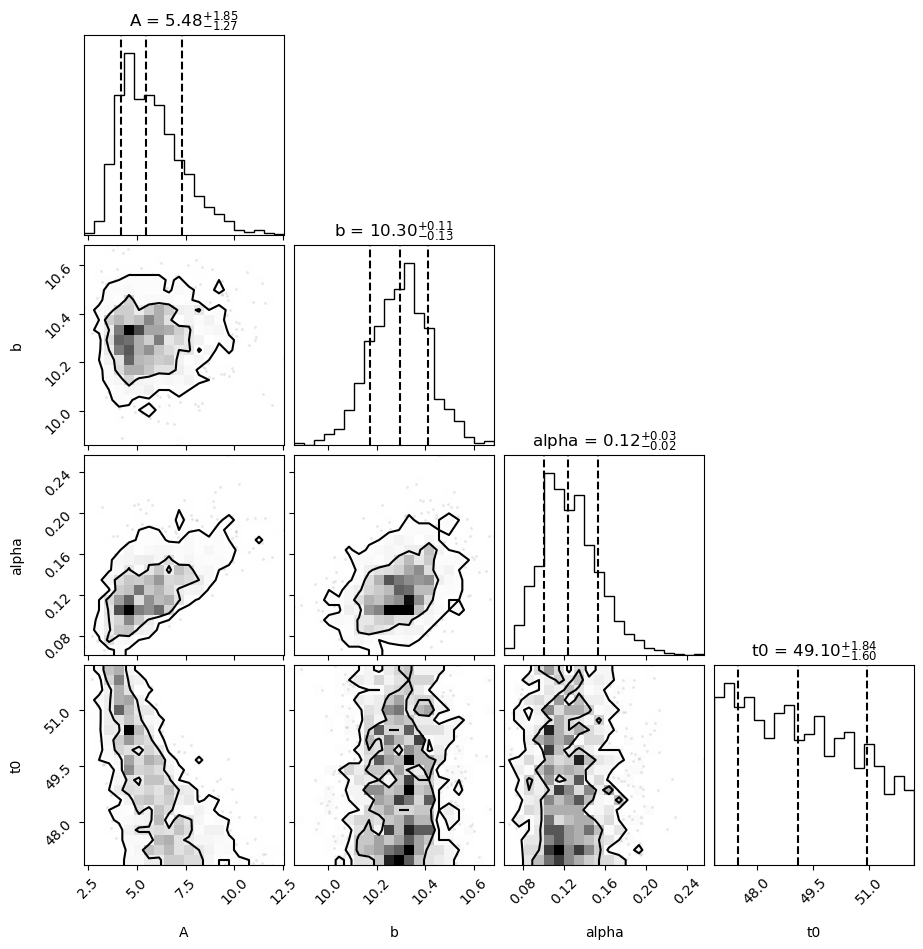

In [8]:
fig = corner.corner(emcee_trace_thin, labels=labels, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], show_titles=True)

Let's plot 100 burst-curves upon our data:

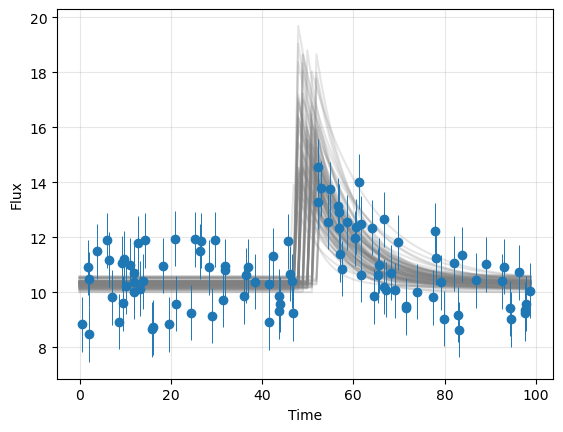

In [25]:
samples = [np.random.choice(emcee_trace_thin[:,i], size = 100) for i in range(len(theta_test))]
x_grid = np.linspace(0, np.max(time), len(time))
for i in range(100):
    y = model ([samples[0][i], samples[1][i], samples[2][i], samples[3][i]], x_grid)
    plt.plot(x_grid, y, color='gray', alpha=0.2)
    
plt.errorbar(time, flux, yerr=err, fmt='o', elinewidth=0.7)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.grid(alpha=0.3)

The median and 90% credible region of the marginalized distribution for each parameter are:

In [26]:
med = []
for i in range(len(theta_test)):
    low, median, up = np.quantile(emcee_trace_thin[:,i], [0.05, 0.5, 0.95])
    print(f'{labels[i]} = {median} + {up-median} - {median-low}')
    med.append(median)

A = 5.480713719091794 + 3.3426513821737824 - 1.7948831934297438
b = 10.29713907158201 + 0.19272668659808012 - 0.2013867414073811
alpha = 0.1233501178364381 + 0.051979307951679626 - 0.03901155198370067
t0 = 49.09620375271206 + 2.649796407406349 - 2.0636894622626656


The best fit is:

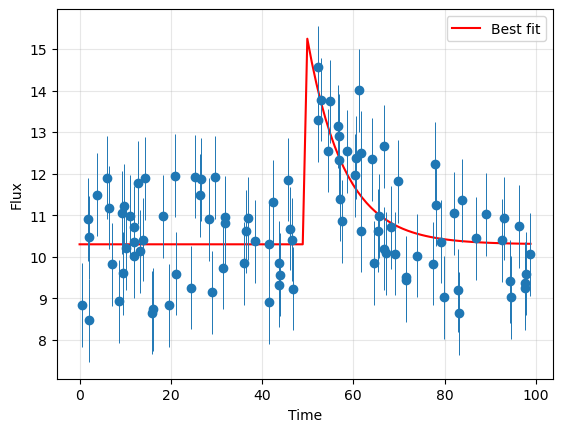

In [28]:
plt.plot(x_grid, model(med, x_grid), color='red', label='Best fit')
plt.legend()
plt.errorbar(time, flux, yerr=err, fmt='o', elinewidth=0.7)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.grid(alpha=0.3)